In [86]:
from google.colab import files
import pandas as pd

In [87]:
# Cargar archivo desde tu computadora
uploaded = files.upload()

Saving fragments_with_umap.csv to fragments_with_umap (5).csv


In [88]:
filename = list(uploaded.keys())[0]
print("Archivo cargado:", filename)

df = pd.read_csv(filename)
df.head()

Archivo cargado: fragments_with_umap (5).csv


,Identifier,Original_SMILES,Fragment_SMILES,Rule,Mode,UMAP_1,UMAP_2
0,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,6.356934,13.177719
1,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[4*]NC1CSSCC(C(=O)NC(C(=O)NCC(=O)NC(CCC[NH+]=C...,Amide,RECAP,8.698808,4.373025
2,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CCC[NH+]=C(N)N)NC(=O)CNC(=O)CNC(=O)...,Amide,RECAP,6.471930,12.961140
3,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)C(CC(C([2H])([2H])[2H])C([2H])([2H])[...,Amide,RECAP,-5.884983,-1.477807
4,AP00195,[2H]C([2H])([2H])C(CC(C(NC1CSSCC(C(NC(C(NCC(NC...,[3*]C(=O)CNC(=O)CNC(=O)C([NH3+])CCC[NH+]=C(N)N,Amide,RECAP,6.492955,12.909265


In [89]:
!pip install rdkit

In [90]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
def pair_similarity(smiles1, smiles2):
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)
        if mol1 is None or mol2 is None:
            return np.nan

        fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, radius=2, nBits=2048)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, radius=2, nBits=2048)

        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except:
        return np.nan

In [92]:
df['Similarity'] = df.apply(
    lambda row: pair_similarity(row['Original_SMILES'], row['Fragment_SMILES']),
    axis=1
)

Se han truncado las últimas 5000 líneas del flujo de salida.
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGenerator
[00:45:05] DEPRECATION WARNING: please use MorganGener

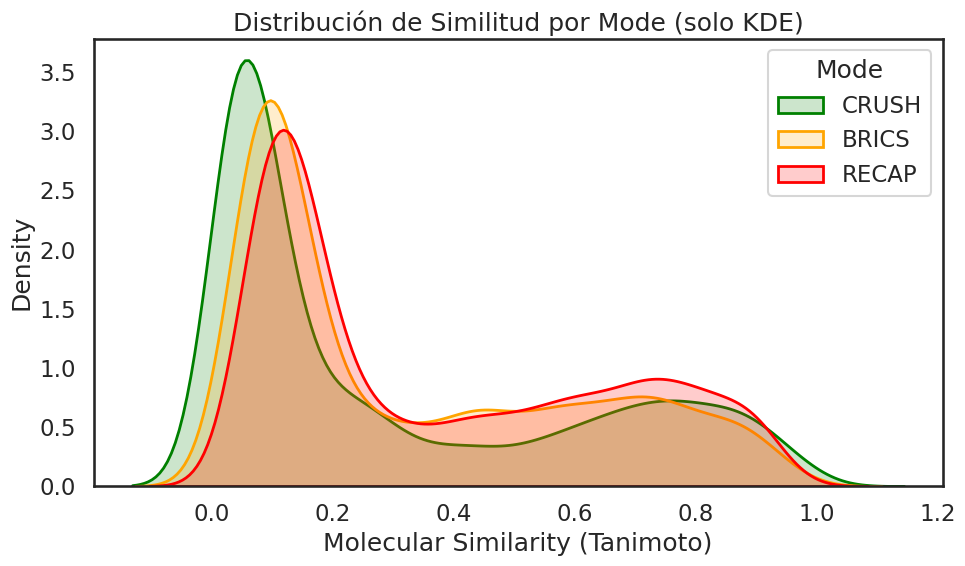

In [93]:
plt.figure(figsize=(10, 6))

# Orden deseado
order = ["CRUSH", "BRICS", "RECAP"]

# Colores específicos
color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red"
}

# Trazar KDE en el orden definido
for mode in order:
    sns.kdeplot(
        data=df[df['Mode'] == mode],
        x='Similarity',
        fill=True,
        alpha=0.2,      # 80% transparente
        color=color_map[mode],
        label=mode,
        linewidth=2
    )

plt.xlabel('Molecular Similarity (Tanimoto)')
plt.ylabel('Density')
plt.title('Distribución de Similitud por Mode (solo KDE)')
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

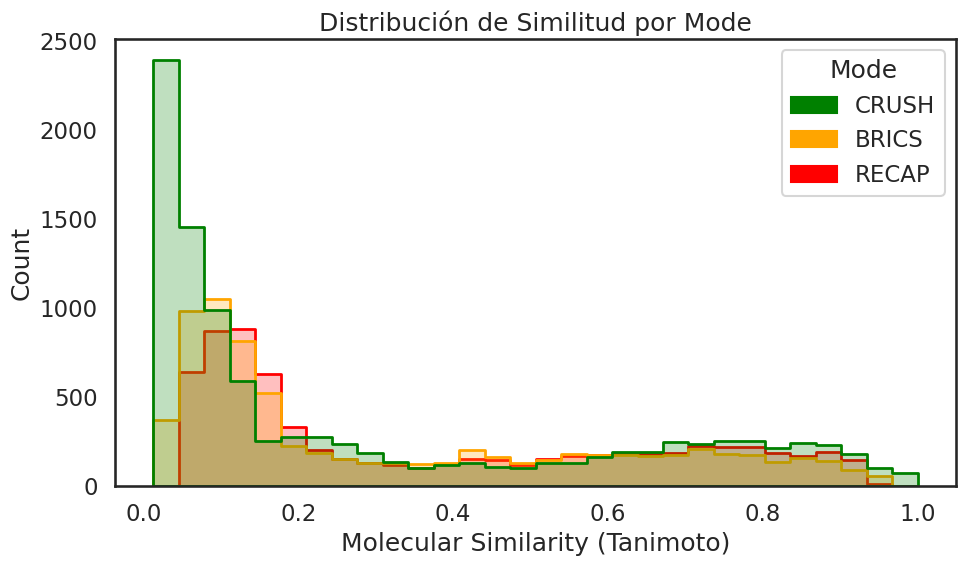

In [94]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))

# Orden deseado
order = ["CRUSH", "BRICS", "RECAP"]

# Colores específicos
color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red"
}

sns.histplot(
    data=df,
    x='Similarity',
    hue='Mode',
    hue_order=order,
    palette=color_map,
    bins=30,
    alpha=0.25,
    element="step",
    linewidth=2,
    legend=False     # <<--- Desactivar leyenda automática
)

# >>> Crear la leyenda manual <<<
patches = [
    mpatches.Patch(color=color_map[m], label=m)
    for m in order
]

plt.legend(handles=patches, title="Mode")

plt.xlabel('Molecular Similarity (Tanimoto)')
plt.ylabel('Count')
plt.title('Distribución de Similitud por Mode')
plt.tight_layout()
plt.show()

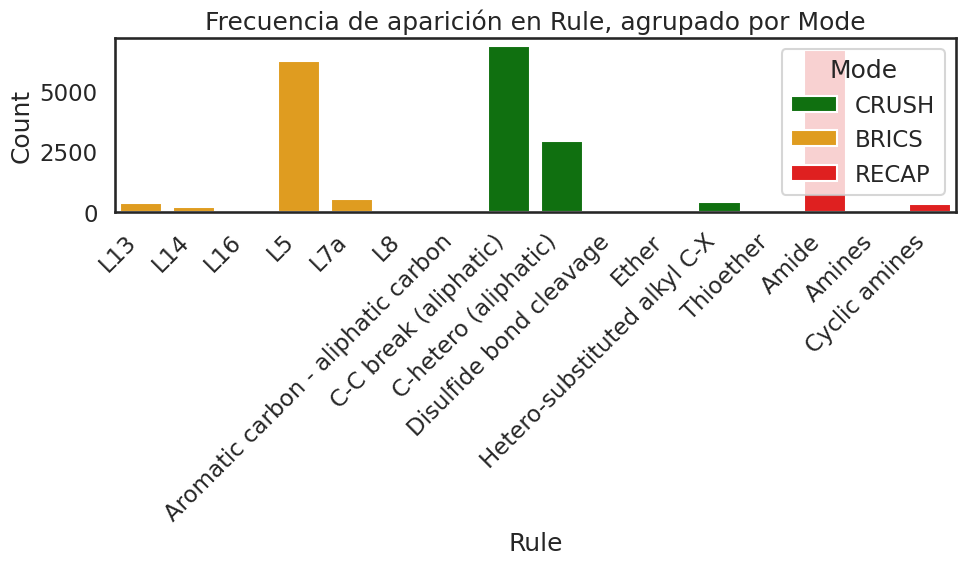

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Calcular frecuencia por Mode y Rule ---
freq_rule_mode = df.groupby(["Mode", "Rule"]).size().reset_index(name="Count")

plt.figure(figsize=(10, 6))

# Orden deseado
order_mode = ["CRUSH", "BRICS", "RECAP"]

# Colores específicos
color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red"
}

# --- Gráfico de barras agrupadas ---
sns.barplot(
    data=freq_rule_mode,
    x="Rule",
    y="Count",
    hue="Mode",
    hue_order=order_mode,     # <<-- Respeta el orden
    palette=color_map         # <<-- Respeta los colores
)

plt.xticks(rotation=45, ha='right')
plt.title('Frecuencia de aparición en Rule, agrupado por Mode')
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

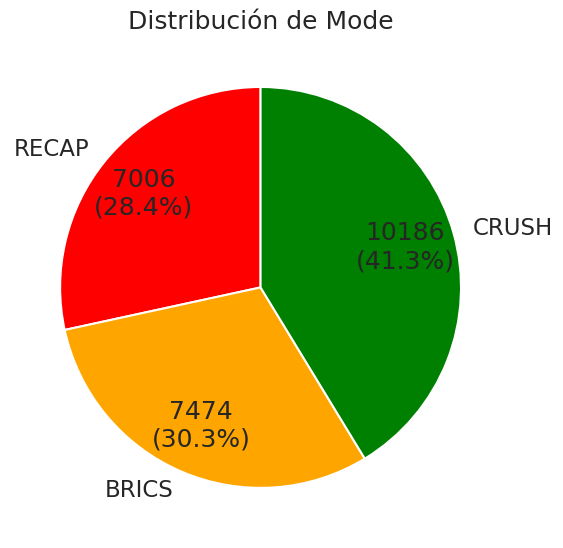

In [96]:
import matplotlib.pyplot as plt

# --- Colores originales ---
color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red",
    "Synthon-based": "#9b59b6"
}

# --- Orden de aparición en el DataFrame ---
ordered_modes = df["Mode"].dropna().unique()

# --- Conteo ---
counts = df["Mode"].value_counts()
total = counts.sum()

# --- Colores en el orden correcto ---
colors = [color_map[m] for m in ordered_modes]

# --- Función para mostrar conteo + porcentaje ---
def autopct_format(pct):
    count = int(round(pct * total / 100.0))
    return f"{count}\n({pct:.1f}%)"

# --- Graficar ---
plt.figure(figsize=(6,6))
plt.pie(
    counts[ordered_modes],
    labels=ordered_modes,
    colors=colors,
    autopct=autopct_format,
    startangle=90,
    pctdistance=0.75
)

plt.title("Distribución de Mode")
plt.tight_layout()
plt.show()

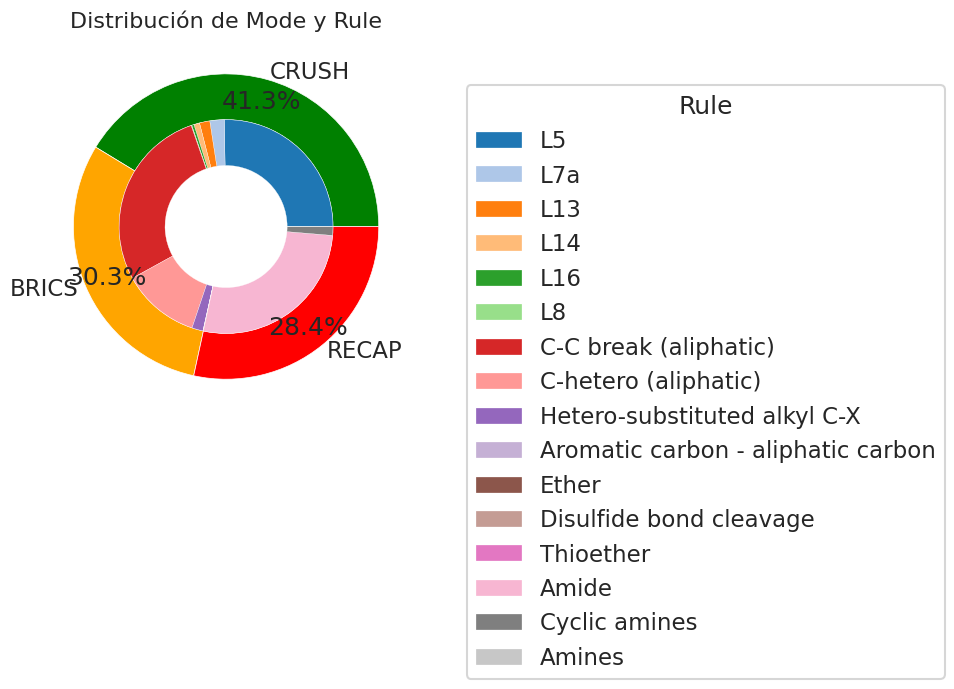

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Asignar colores fijos para Mode ---
color_map = {
    "CRUSH": "green",   # verde
    "BRICS": "orange",   # naranja
    "RECAP": "red"
}

# --- Preparar datos ---
mode_counts = df['Mode'].value_counts()
mode_counts = mode_counts.reindex(color_map.keys(), fill_value=0)
outer_colors = [color_map[m] for m in mode_counts.index]

# --- Conteo de Rule agrupado por Mode ---
rule_counts = df.groupby('Mode')['Rule'].value_counts()

# --- Asignar un color único por cada Rule ---
unique_rules = rule_counts.index.get_level_values(1).unique()

rule_palette = sns.color_palette("tab20", len(unique_rules))
rule_color_map = {rule: rule_palette[i] for i, rule in enumerate(unique_rules)}

inner_colors = [rule_color_map[rule] for (_, rule) in rule_counts.index]
inner_sizes = rule_counts.values

plt.figure(figsize=(10, 10))

# --- ANILLO EXTERNO (Mode) ---
wedges1, texts1, autotexts1 = plt.pie(
    mode_counts,
    labels=mode_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=0.5)
)

# --- ANILLO INTERNO (Rule) ---
wedges2, texts2 = plt.pie(
    inner_sizes,
    labels=None,
    colors=inner_colors,
    radius=0.7,
    wedgeprops=dict(width=0.3, edgecolor='white', linewidth=0.2)
)

# --- Leyenda para Rule ---
plt.legend(
    wedges2,
    [rule for rule in unique_rules],
    title="Rule",
    bbox_to_anchor=(1.1, 0.9)
)

plt.title("Distribución de Mode y Rule", fontsize=16)
plt.tight_layout()

# -------- EXPORTAR FIGURA EN ALTA RESOLUCIÓN --------
plt.savefig("mode_rule_plot.png", dpi=1200, bbox_inches="tight")  # ← AQUÍ

plt.show()

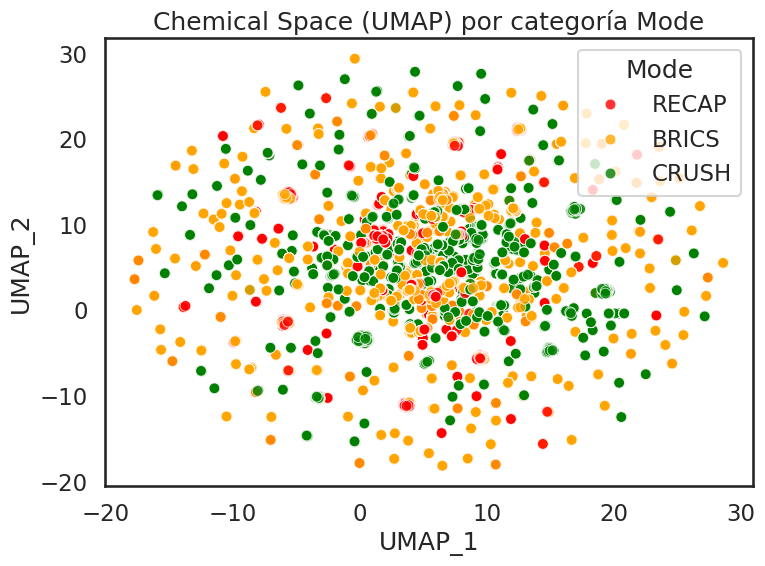

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Colores que ya definiste ---
color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red",
    "Synthon-based": "#9b59b6"
}

# --- Obtener orden de aparición real ---
ordered_modes = df["Mode"].dropna().unique()

# --- Crear lista de colores en ese orden ---
palette = [color_map[m] for m in ordered_modes]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="UMAP_1",
    y="UMAP_2",
    hue="Mode",
    palette=palette,       # ← Colores correctos
    hue_order=ordered_modes,  # ← Orden correcto
    alpha=0.8,
    s=60
)

plt.title("Chemical Space (UMAP) por categoría Mode")
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

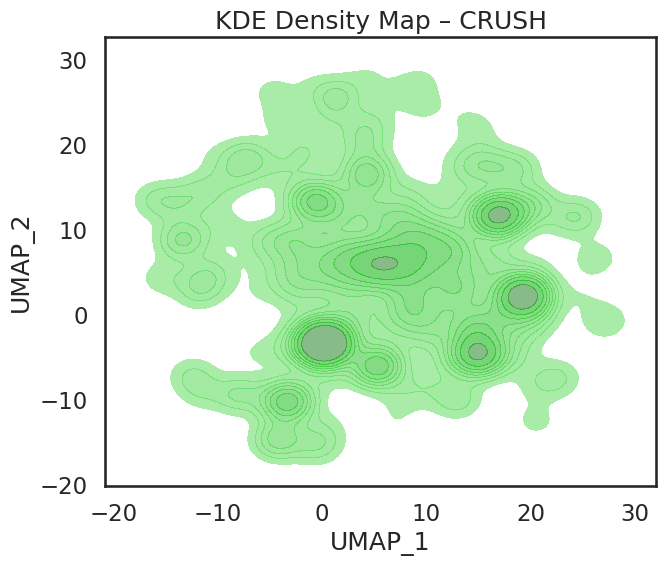

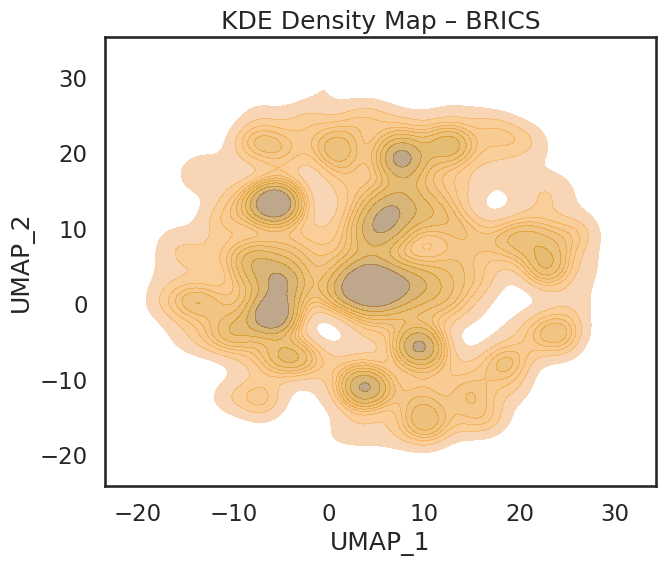

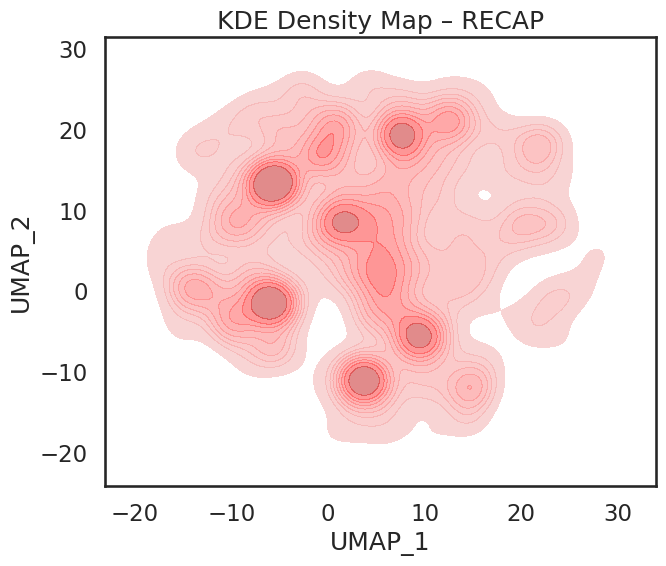

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set(style="white", context="talk")

color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red"
}

modes = ["CRUSH", "BRICS", "RECAP"]

# ================================
# (1) KDE por categoría (submuestreo)
# ================================
N = 20000  # número óptimo para KDE por clase

for mode in modes:
    df_mode = df[df["Mode"] == mode]

    # Subsample
    df_sample = df_mode.sample(
        n=min(N, df_mode.shape[0]),
        random_state=0
    )

    plt.figure(figsize=(7, 6))

    sns.kdeplot(
        x=df_sample["UMAP_1"],
        y=df_sample["UMAP_2"],
        fill=True,
        color=color_map[mode],
        alpha=0.55,
        bw_adjust=0.8,
        thresh=0.05
    )

    plt.title(f"KDE Density Map – {mode}", fontsize=18)
    plt.xlabel("UMAP_1")
    plt.ylabel("UMAP_2")
    plt.tight_layout()
    plt.show()

In [100]:
import numpy as np
import pandas as pd

# =============================================
# (1) GRILLA GLOBAL
# =============================================
bins = 250

H_global, xedges, yedges = np.histogram2d(
    df["UMAP_1"],
    df["UMAP_2"],
    bins=bins
)

global_occupied = (H_global > 0).astype(int)

# =============================================
# (2) MATRICES DE OCUPACIÓN POR CATEGORÍA
# =============================================
modes = df["Mode"].unique()
occ_matrices = {}

for mode in modes:
    df_mode = df[df["Mode"] == mode]

    H, _, _ = np.histogram2d(
        df_mode["UMAP_1"],
        df_mode["UMAP_2"],
        bins=bins
    )

    occ = (H > 0).astype(int)
    occ_matrices[mode] = occ

# =============================================
# (3) MATRIZ DE SOLAPAMIENTO NORMALIZADO (Jaccard)
# =============================================
overlap_matrix = pd.DataFrame(index=modes, columns=modes, dtype=float)

for m1 in modes:
    for m2 in modes:
        A = occ_matrices[m1]
        B = occ_matrices[m2]

        intersection = np.sum((A == 1) & (B == 1))
        union = np.sum((A == 1) | (B == 1))

        # evitar división por cero
        jaccard = intersection / union if union > 0 else 0

        overlap_matrix.loc[m1, m2] = jaccard

print("\n=== MATRIZ DE SOLAPAMIENTO NORMALIZADA (Jaccard) ===\n")
display(overlap_matrix.style.background_gradient(cmap="viridis"))


=== MATRIZ DE SOLAPAMIENTO NORMALIZADA (Jaccard) ===



,RECAP,BRICS,CRUSH
RECAP,1.000000,0.020789,0.018574
BRICS,0.020789,1.000000,0.016771
CRUSH,0.018574,0.016771,1.000000


In [101]:
!pip install matplotlib-venn

Total de celdas realmente ocupadas: 1472


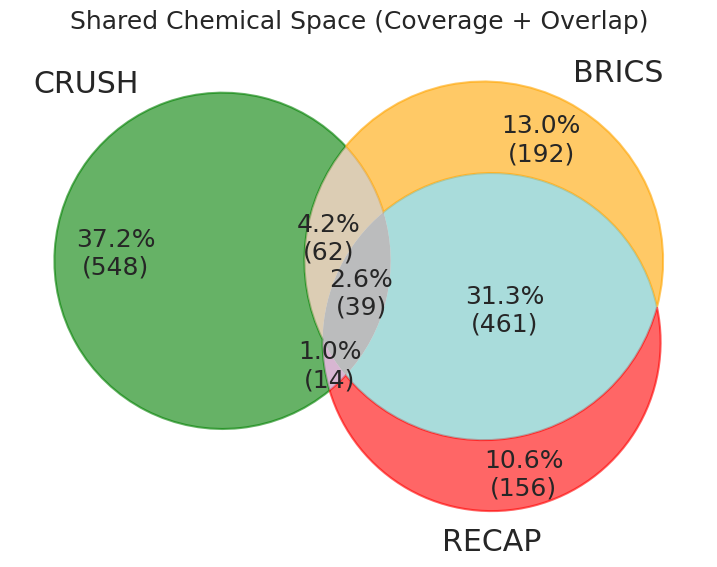

In [102]:
# ============================================
# IMPORTS NECESARIOS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# ============================================
# CONFIGURACIÓN GENERAL
# ============================================
bins = 250  # resolución de la grilla 2D

# Define tus modos PRINCIPALES
modes = ["CRUSH", "BRICS", "RECAP"]

# Cada modo DEBE existir como columna en df para filtrar por método
# Ejemplo: df["mode"] contiene el nombre del método usado para generar el compuesto


# ============================================
# (1) CALCULAR CELDAS OCUPADAS (GLOBAL)
# ============================================
H_global, xedges, yedges = np.histogram2d(df["UMAP_1"], df["UMAP_2"], bins=bins)
global_occ = (H_global > 0).astype(int)
total_real = np.sum(global_occ)

print("Total de celdas realmente ocupadas:", total_real)


# ============================================
# (2) CALCULAR CELDAS OCUPADAS POR CADA MODO
# ============================================

# Diccionario para almacenar sets de celdas por modo
occ_sets = {}

for mode in modes:
    df_mode = df[df["Mode"] == mode]

    # Histograma del modo actual
    H_mode, _, _ = np.histogram2d(
        df_mode["UMAP_1"], df_mode["UMAP_2"], bins=[xedges, yedges]
    )

    # Guardar como conjunto de celdas ocupadas
    cells = set(zip(*np.where(H_mode > 0)))  # posiciones (i,j)

    occ_sets[mode] = cells

# Para simplicidad
A, B, C = modes


# ============================================
# (3) CALCULAR REGIONES DEL VENN
# ============================================

a_only = len(occ_sets[A] - occ_sets[B] - occ_sets[C])
b_only = len(occ_sets[B] - occ_sets[A] - occ_sets[C])
c_only = len(occ_sets[C] - occ_sets[A] - occ_sets[B])

ab = len((occ_sets[A] & occ_sets[B]) - occ_sets[C])
ac = len((occ_sets[A] & occ_sets[C]) - occ_sets[B])
bc = len((occ_sets[B] & occ_sets[C]) - occ_sets[A])

abc = len(occ_sets[A] & occ_sets[B] & occ_sets[C])

counts = [a_only, b_only, ab, c_only, ac, bc, abc]
total = sum(counts)


# ============================================
# (4) DIAGRAMA DE VENN CON COLORES PERSONALIZADOS
# ============================================

color_map = {
    "CRUSH": "green",
    "BRICS": "orange",
    "RECAP": "red"
}

plt.figure(figsize=(9, 9))

v = venn3(
    subsets=counts,
    set_labels=(A, B, C)
)

# Aplicar colores a cada círculo
if v.get_patch_by_id("100") and A in color_map:
    v.get_patch_by_id("100").set_color(color_map[A])
if v.get_patch_by_id("010") and B in color_map:
    v.get_patch_by_id("010").set_color(color_map[B])
if v.get_patch_by_id("001") and C in color_map:
    v.get_patch_by_id("001").set_color(color_map[C])

# Transparencias
for pid in ["100","010","110","001","101","011","111"]:
    patch = v.get_patch_by_id(pid)
    if patch:
        patch.set_alpha(0.60)


# ============================================
# (5) AGREGAR PORCENTAJE Y CONTEO
# ============================================
labels = ["100","010","110","001","101","011","111"]

for label_id, count in zip(labels, counts):
    label = v.get_label_by_id(label_id)
    if label:
        pct = (count / total) * 100 if total > 0 else 0
        label.set_text(f"{pct:.1f}%\n({count})")


plt.title("Shared Chemical Space (Coverage + Overlap)")
plt.show()